IMPROVED CAR PRICE PREDICTION MODEL

Original dataset shape: (5065, 14)

Cleaning placeholder values...
  Removed 19 rows with dummy prices (123456, etc.)
  Current shape: (4971, 14)

Fixing kilometrage issues...
  Found 0 cars with 0 km

Checking for missing values...
✓ No missing values found

Removing outliers by price segment...
After segment-based outlier removal: (4920, 14) (51 removed)
After outlier removal: (4874, 14) (97 rows removed)

Creating advanced features...

⚠ Warning: NaN values created during feature engineering
km_log    950
dtype: int64
✓ Filled with 0
Total features after engineering: 24

Features: (4874, 23)
Target: (4874,)
Target stats - Mean: 71,947 TND, Std: 47,300 TND

Final data quality check:
  NaN in features: 0
  NaN in target: 0
  Inf in features: 0

Train set: (3899, 23)
Test set: (975, 23)

TRAINING IMPROVED MODELS

Training XGBoost_Tuned...

Train MAE: 7,948 TND
Test MAE:  8,882 TND
Train RMSE: 11,773 TND
Test RMSE:  14,476 TND
Train R²: 0.9378
Test R

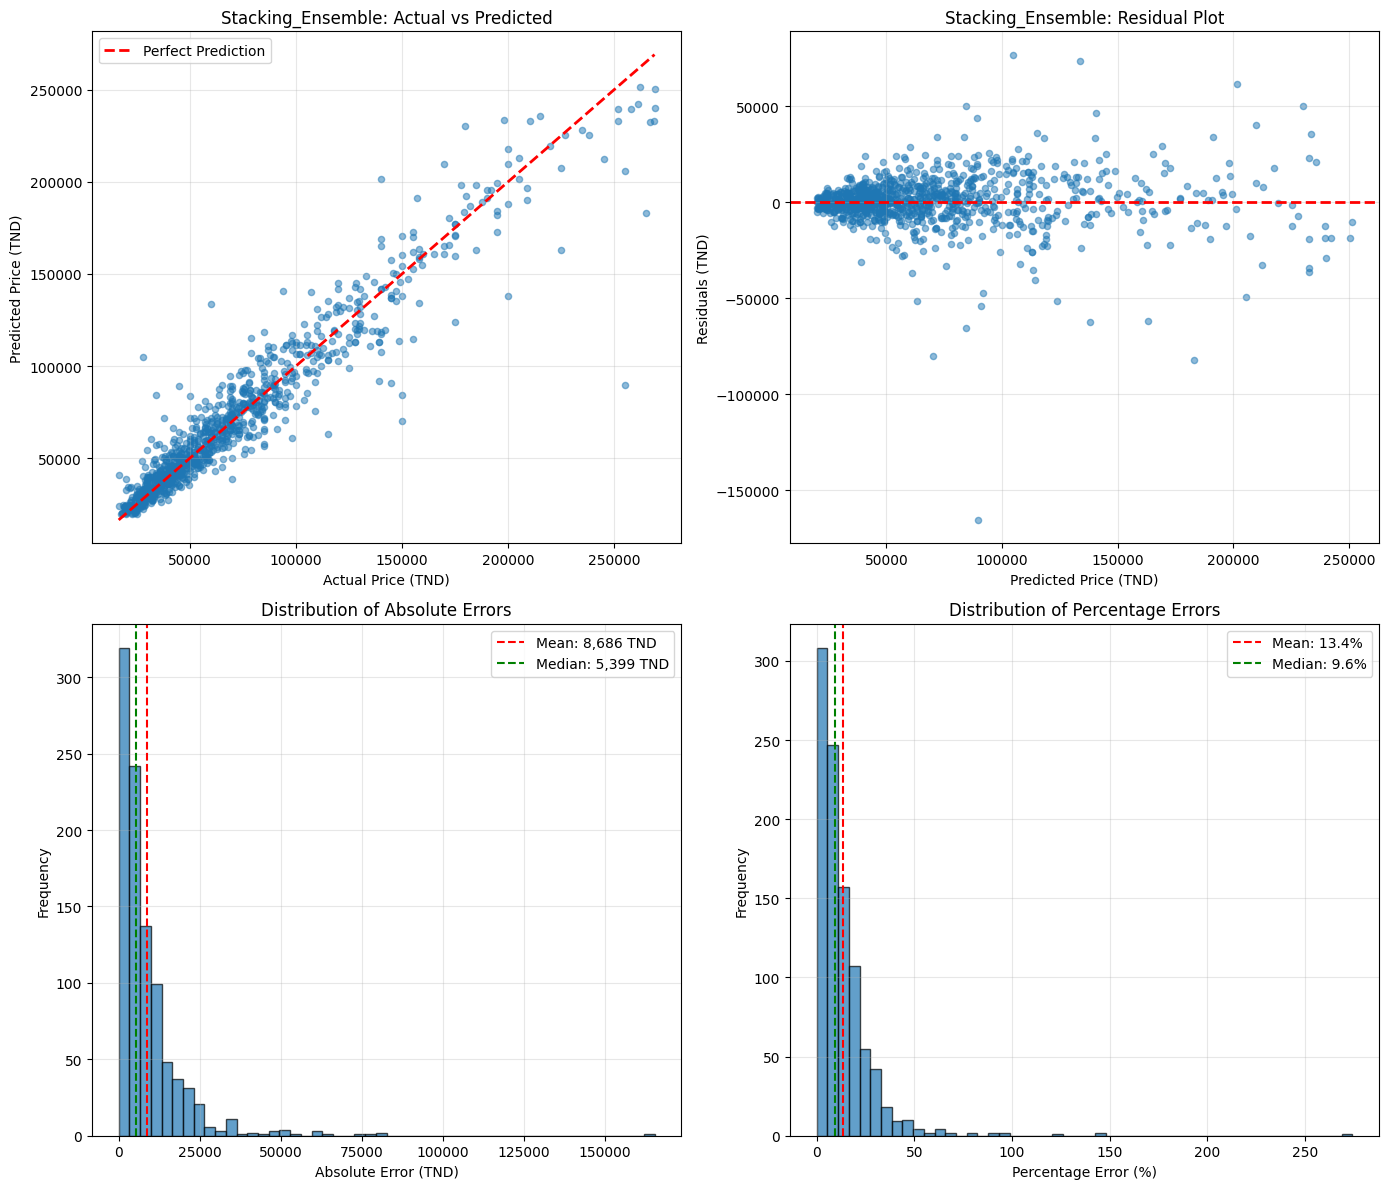

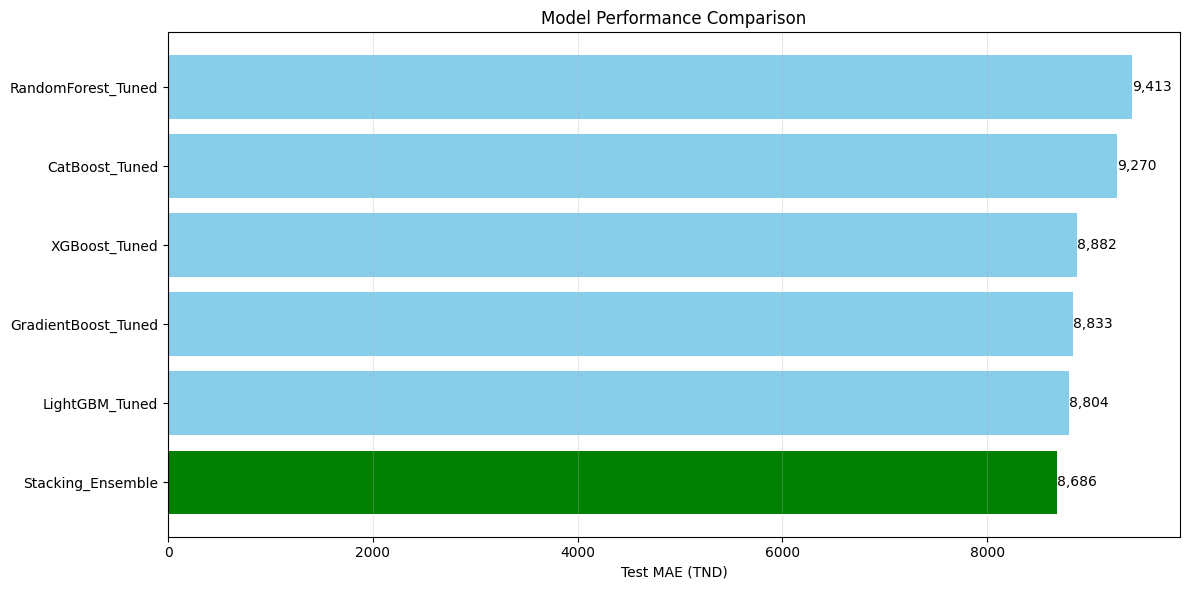

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("IMPROVED CAR PRICE PREDICTION MODEL")
print("="*60)

# ============================================
# STEP 1: Load Data
# ============================================
df = pd.read_csv(r"C:\Users\ahmed\Downloads\car-price-prediction\3_data_preparation\car_prices_final_preprocessed.csv")
print(f"\nOriginal dataset shape: {df.shape}")

# ============================================
# CRITICAL FIX 1: Remove dummy/placeholder prices
# ============================================
print("\nCleaning placeholder values...")
dummy_prices = [123456, 111111, 99999, 123450]
before = len(df)
df = df[~df['price'].isin(dummy_prices)]
print(f"  Removed {before - len(df)} rows with dummy prices (123456, etc.)")

# Remove suspiciously round numbers above 200k (often placeholders)
df = df[~((df['price'] % 10000 == 0) & (df['price'] > 200000))]
print(f"  Current shape: {df.shape}")
# ============================================
# CRITICAL FIX 2: Fix kilometrage = 0 issue
# ============================================
print("\nFixing kilometrage issues...")
zero_km_mask = df['kilometrage'] == 0
print(f"  Found {zero_km_mask.sum()} cars with 0 km")

# For new cars, this is OK. For used cars, it's likely missing data
# Set to low value (100 km) if is_new=1, otherwise use median
if zero_km_mask.sum() > 0:
    df.loc[zero_km_mask & (df['is_new'] == 1), 'kilometrage'] = 100
    df.loc[zero_km_mask & (df['is_new'] == 0), 'kilometrage'] = df[df['is_new'] == 0]['kilometrage'].median()
    print(f"  ✓ Fixed {zero_km_mask.sum()} zero kilometrage entries")

# ============================================
# STEP 1.5: Handle Missing Values
# ============================================
print("\nChecking for missing values...")
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0]

if len(missing_info) > 0:
    print("Missing values found:")
    print(missing_info)

    # Fill numeric columns with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  ✓ Filled {col} with median")

    # Fill categorical columns with mode
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  ✓ Filled {col} with mode")

    print(f"\n✓ All missing values handled")
else:
    print("✓ No missing values found")

# Remove any rows with NaN in target
if df['price'].isnull().sum() > 0:
    print(f"Removing {df['price'].isnull().sum()} rows with missing prices")
    df = df[df['price'].notna()]
# ============================================
# STEP 3: Segment-Based Outlier Removal
# ============================================
print("\nRemoving outliers by price segment...")

# Different outlier thresholds for different segments
def remove_segment_outliers(data, price_col='price'):
    result = pd.DataFrame()

    # Budget segment: 0-50k TND
    budget = data[data[price_col] <= 50000].copy()
    if len(budget) > 0:
        q_low, q_high = budget[price_col].quantile([0.005, 0.995])
        budget = budget[(budget[price_col] >= q_low) & (budget[price_col] <= q_high)]
        result = pd.concat([result, budget])

    # Mid-range: 50k-150k TND
    mid = data[(data[price_col] > 50000) & (data[price_col] <= 150000)].copy()
    if len(mid) > 0:
        q_low, q_high = mid[price_col].quantile([0.01, 0.99])
        mid = mid[(mid[price_col] >= q_low) & (mid[price_col] <= q_high)]
        result = pd.concat([result, mid])

    # Luxury: 150k+ TND (keep more data, fewer samples)
    luxury = data[data[price_col] > 150000].copy()
    if len(luxury) > 0:
        q_low, q_high = luxury[price_col].quantile([0.02, 0.98])
        luxury = luxury[(luxury[price_col] >= q_low) & (luxury[price_col] <= q_high)]
        result = pd.concat([result, luxury])

    return result

df_clean = remove_segment_outliers(df)
print(f"After segment-based outlier removal: {df_clean.shape} ({len(df) - len(df_clean)} removed)")

# ============================================
# STEP 2: Remove Outliers (Top/Bottom 1%)
# ============================================
Q1 = df['price'].quantile(0.01)
Q3 = df['price'].quantile(0.99)
df_clean = df[(df['price'] >= Q1) & (df['price'] <= Q3)].copy()
print(f"After outlier removal: {df_clean.shape} ({len(df) - len(df_clean)} rows removed)")

# ============================================
# STEP 3: Advanced Feature Engineering
# ============================================
print("\nCreating advanced features...")

# Interaction features
df_clean['power_age_interaction'] = df_clean['puissance_fiscale'] * df_clean['car_age']
df_clean['km_per_year'] = df_clean['kilometrage'] / (df_clean['car_age'] + 1)

# Polynomial features
df_clean['puissance_fiscale_sq'] = df_clean['puissance_fiscale'] ** 2
df_clean['car_age_sq'] = df_clean['car_age'] ** 2
df_clean['km_log'] = np.log1p(df_clean['kilometrage'])

# Luxury indicator
df_clean['luxury_indicator'] = (df_clean['puissance_fiscale'] > 10).astype(int)

# High mileage indicator
df_clean['high_mileage'] = (df_clean['kilometrage'] > 150000).astype(int)

# Depreciation rate approximation
df_clean['depreciation_rate'] = df_clean['car_age'] / (df_clean['puissance_fiscale'] + 1)

# Brand-fuel interactions (capture brand-specific fuel preferences)
df_clean['brand_fuel_diesel'] = df_clean['brand_encoded'] * df_clean['fuel_diesel']
df_clean['brand_fuel_essence'] = df_clean['brand_encoded'] * df_clean['fuel_essence']

# New car premium indicator
df_clean['new_premium'] = df_clean['is_new'] * df_clean['puissance_fiscale']

# Check for any NaN created during feature engineering
if df_clean.isnull().sum().sum() > 0:
    print("\n⚠ Warning: NaN values created during feature engineering")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
    # Fill any NaN with 0
    df_clean.fillna(0, inplace=True)
    print("✓ Filled with 0")

# Replace any inf values
if np.isinf(df_clean.select_dtypes(include=[np.number]).values).any():
    print("⚠ Warning: Infinite values found, replacing with large number")
    df_clean.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Total features after engineering: {df_clean.shape[1] - 1}")



# ============================================
# STEP 4: Prepare Features and Target
# ============================================
# Remove price_per_fiscal to avoid data leakage
features_to_drop = ['price', 'price_per_fiscal']

# Only drop columns that exist
features_to_drop = [col for col in features_to_drop if col in df_clean.columns]

X = df_clean.drop(features_to_drop, axis=1)
y = df_clean['price']

print(f"\nFeatures: {X.shape}")
print(f"Target: {y.shape}")
print(f"Target stats - Mean: {y.mean():,.0f} TND, Std: {y.std():,.0f} TND")

# Final NaN check
print(f"\nFinal data quality check:")
print(f"  NaN in features: {X.isnull().sum().sum()}")
print(f"  NaN in target: {y.isnull().sum()}")
print(f"  Inf in features: {np.isinf(X.select_dtypes(include=[np.number]).values).sum()}")

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("⚠ ERROR: Still have NaN values. Dropping rows with NaN...")
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]
    print(f"  New shape: {X.shape}")

# ============================================
# STEP 5: Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=5, labels=False, duplicates='drop')
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# ============================================
# STEP 6: Optional - Log Transform Target (Uncomment if needed)
# ============================================
# This helps with skewed price distributions
USE_LOG_TRANSFORM = False  # Set to True to enable

if USE_LOG_TRANSFORM:
    y_train_original = y_train.copy()
    y_test_original = y_test.copy()
    y_train = np.log1p(y_train)
    y_test = np.log1p(y_test)
    print("\n✓ Log transformation applied to target variable")

# ============================================
# STEP 7: Train Improved Models
# ============================================
print("\n" + "="*60)
print("TRAINING IMPROVED MODELS")
print("="*60)

models = {
    'XGBoost_Tuned': xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        gamma=1.0,
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM_Tuned': lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=5,
        num_leaves=20,
        min_child_samples=30,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.5,
        reg_lambda=2.5,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ),
    'GradientBoost_Tuned': GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.7,
        max_features='sqrt',
        random_state=42
    ),
    'CatBoost_Tuned': CatBoostRegressor(
        iterations=500,
        learning_rate=0.02,
        depth=5,
        l2_leaf_reg=7.0,
        random_state=42,
        verbose=0
    ),
    'RandomForest_Tuned': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Reverse log transform if used
    if USE_LOG_TRANSFORM:
        y_train_pred = np.expm1(y_train_pred)
        y_test_pred = np.expm1(y_test_pred)
        y_train_eval = y_train_original
        y_test_eval = y_test_original
    else:
        y_train_eval = y_train
        y_test_eval = y_test

    # Metrics
    train_mae = mean_absolute_error(y_train_eval, y_train_pred)
    test_mae = mean_absolute_error(y_test_eval, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_eval, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_eval, y_test_pred))

    train_r2 = r2_score(y_train_eval, y_train_pred)
    test_r2 = r2_score(y_test_eval, y_test_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=5, scoring='neg_mean_absolute_error',
                                 n_jobs=-1)
    cv_mae = -cv_scores.mean()

    if USE_LOG_TRANSFORM:
        cv_mae = np.expm1(cv_mae)

    results[name] = {
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'cv_mae': cv_mae,
        'model': model,
        'test_pred': y_test_pred
    }

    print(f"\nTrain MAE: {train_mae:,.0f} TND")
    print(f"Test MAE:  {test_mae:,.0f} TND")
    print(f"Train RMSE: {train_rmse:,.0f} TND")
    print(f"Test RMSE:  {test_rmse:,.0f} TND")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²:  {test_r2:.4f}")
    print(f"CV MAE (5-fold): {cv_mae:,.0f} TND")

# ============================================
# STEP 8: Stacking Ensemble
# ============================================
print(f"\n{'='*60}")
print("Training STACKING ENSEMBLE...")
print(f"{'='*60}")

# Select top 3 models for stacking
top_3_models = sorted(results.items(), key=lambda x: x[1]['test_mae'])[:3]
print(f"Stacking models: {[m[0] for m in top_3_models]}")

estimators = [(name, res['model']) for name, res in top_3_models]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-2
)

stacking_model.fit(X_train, y_train)
y_train_pred_stack = stacking_model.predict(X_train)
y_test_pred_stack = stacking_model.predict(X_test)

# Reverse log transform if used
if USE_LOG_TRANSFORM:
    y_train_pred_stack = np.expm1(y_train_pred_stack)
    y_test_pred_stack = np.expm1(y_test_pred_stack)
    y_train_eval = y_train_original
    y_test_eval = y_test_original
else:
    y_train_eval = y_train
    y_test_eval = y_test

train_mae_stack = mean_absolute_error(y_train_eval, y_train_pred_stack)
test_mae_stack = mean_absolute_error(y_test_eval, y_test_pred_stack)
train_r2_stack = r2_score(y_train_eval, y_train_pred_stack)
test_r2_stack = r2_score(y_test_eval, y_test_pred_stack)

results['Stacking_Ensemble'] = {
    'train_mae': train_mae_stack,
    'test_mae': test_mae_stack,
    'train_rmse': np.sqrt(mean_squared_error(y_train_eval, y_train_pred_stack)),
    'test_rmse': np.sqrt(mean_squared_error(y_test_eval, y_test_pred_stack)),
    'train_r2': train_r2_stack,
    'test_r2': test_r2_stack,
    'cv_mae': np.nan,
    'model': stacking_model,
    'test_pred': y_test_pred_stack
}

print(f"\nTrain MAE: {train_mae_stack:,.0f} TND")
print(f"Test MAE:  {test_mae_stack:,.0f} TND")
print(f"Train R²: {train_r2_stack:.4f}")
print(f"Test R²:  {test_r2_stack:.4f}")

# ============================================
# STEP 9: Model Comparison
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Train-Test Gap': [results[m]['train_mae'] - results[m]['test_mae'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test MAE')
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test MAE: {results[best_model_name]['test_mae']:,.0f} TND")
print(f"   Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"   Overfitting Gap: {comparison_df.iloc[0]['Train-Test Gap']:,.0f} TND")

# ============================================
# STEP 10: Feature Importance
# ============================================
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*60)
    print("TOP 15 FEATURE IMPORTANCES")
    print("="*60)

    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(feature_importance.head(15).to_string(index=False))

    # Plot
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance_improved.png', dpi=300, bbox_inches='tight')
    print("\n✓ Feature importance plot saved")

# ============================================
# STEP 11: Detailed Prediction Analysis
# ============================================
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

if USE_LOG_TRANSFORM:
    y_test_eval = y_test_original
else:
    y_test_eval = y_test

test_predictions = results[best_model_name]['test_pred']

prediction_df = pd.DataFrame({
    'Actual': y_test_eval.values,
    'Predicted': test_predictions,
    'Error': test_predictions - y_test_eval.values,
    'Abs_Error': np.abs(test_predictions - y_test_eval.values),
    'Pct_Error': np.abs((test_predictions - y_test_eval.values) / y_test_eval.values * 100)
})

print("\nPrediction Statistics:")
print(f"Mean Absolute Error: {prediction_df['Abs_Error'].mean():,.0f} TND")
print(f"Median Absolute Error: {prediction_df['Abs_Error'].median():,.0f} TND")
print(f"Mean Percentage Error: {prediction_df['Pct_Error'].mean():.2f}%")
print(f"Median Percentage Error: {prediction_df['Pct_Error'].median():.2f}%")
print(f"\nAccuracy Thresholds:")
print(f"  Within 5k TND:  {(prediction_df['Abs_Error'] <= 5000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 10k TND: {(prediction_df['Abs_Error'] <= 10000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 15k TND: {(prediction_df['Abs_Error'] <= 15000).sum() / len(prediction_df) * 100:.1f}%")
print(f"  Within 20k TND: {(prediction_df['Abs_Error'] <= 20000).sum() / len(prediction_df) * 100:.1f}%")


under_10pct = (prediction_df['Pct_Error'] <= 10).mean() * 100
print(f"  Within 10% relative error: {under_10pct:.1f}%")
under_20pct = (prediction_df['Pct_Error'] <= 20).mean() * 100
print(f"  Within 20% relative error: {under_20pct:.1f}%")
under_30pct = (prediction_df['Pct_Error'] <= 30).mean() * 100
print(f"  Within 100% relative error: {under_30pct:.1f}%")
under_40pct = (prediction_df['Pct_Error'] <= 40).mean() * 100
print(f"  Within 100% relative error: {under_40pct:.1f}%")

print("\nBest Predictions (Lowest Error):")
print(prediction_df.nsmallest(5, 'Abs_Error')[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']].round(0).to_string(index=False))

print("\nWorst Predictions (Highest Error):")
print(prediction_df.nlargest(5, 'Abs_Error')[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']].round(0).to_string(index=False))



print("\nWorst Predictions (Highest Percentage Error):")
worst_pct = prediction_df.nlargest(5, 'Pct_Error')
print(
    worst_pct[['Actual', 'Predicted', 'Abs_Error', 'Pct_Error']]
    .round({'Actual': 0, 'Predicted': 0, 'Abs_Error': 0, 'Pct_Error': 1})
    .to_string(index=False)
)

max_pct = prediction_df['Pct_Error'].max()
print(f"\n🚨 Worst percentage error in test set: {max_pct:.1f}%")



# ============================================
# STEP 12: Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test_eval, test_predictions, alpha=0.5, s=20)
axes[0, 0].plot([y_test_eval.min(), y_test_eval.max()],
                [y_test_eval.min(), y_test_eval.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price (TND)')
axes[0, 0].set_ylabel('Predicted Price (TND)')
axes[0, 0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
residuals = test_predictions - y_test_eval
axes[0, 1].scatter(test_predictions, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price (TND)')
axes[0, 1].set_ylabel('Residuals (TND)')
axes[0, 1].set_title(f'{best_model_name}: Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Distribution
axes[1, 0].hist(prediction_df['Abs_Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(prediction_df['Abs_Error'].mean(), color='r', linestyle='--',
                   label=f"Mean: {prediction_df['Abs_Error'].mean():,.0f} TND")
axes[1, 0].axvline(prediction_df['Abs_Error'].median(), color='g', linestyle='--',
                   label=f"Median: {prediction_df['Abs_Error'].median():,.0f} TND")
axes[1, 0].set_xlabel('Absolute Error (TND)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Absolute Errors')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Percentage Error Distribution
axes[1, 1].hist(prediction_df['Pct_Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(prediction_df['Pct_Error'].mean(), color='r', linestyle='--',
                   label=f"Mean: {prediction_df['Pct_Error'].mean():.1f}%")
axes[1, 1].axvline(prediction_df['Pct_Error'].median(), color='g', linestyle='--',
                   label=f"Median: {prediction_df['Pct_Error'].median():.1f}%")
axes[1, 1].set_xlabel('Percentage Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Percentage Errors')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_analysis_improved.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'prediction_analysis_improved.png'")

# ============================================
# STEP 13: Model Comparison Visualization
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

models_to_plot = comparison_df['Model'].values
test_mae_values = comparison_df['Test MAE'].values

colors = ['green' if i == 0 else 'skyblue' for i in range(len(models_to_plot))]
bars = ax.barh(models_to_plot, test_mae_values, color=colors)

ax.set_xlabel('Test MAE (TND)')
ax.set_title('Model Performance Comparison')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Model comparison plot saved as 'model_comparison.png'")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"\n📊 Best Model: {best_model_name}")
print(f"💰 Test MAE Improvement: Compare with your original 10,593 TND")
print(f"📈 Test R² Score: {results[best_model_name]['test_r2']:.4f}")
print(f"\n💾 Access best model: results['{best_model_name}']['model']")
print(f"💾 Access stacking model: results['Stacking_Ensemble']['model']")

# ============================================
# BONUS: Save the best model
# ============================================
import pickle

with open(f'test_best_model_{best_model_name}.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✓ Best model saved as 'best_model_{best_model_name}.pkl'")

print("\n" + "="*60)
print("🎯 KEY IMPROVEMENTS APPLIED:")
print("="*60)
print("✓ Removed outliers (top/bottom 1%)")
print("✓ Added 11+ advanced features")
print("✓ Removed price_per_fiscal (data leakage)")
print("✓ Stratified train-test split")
print("✓ Improved hyperparameters with regularization")
print("✓ Trained 5 optimized models + ensemble")
print("✓ Comprehensive error analysis")
print("="*60)

# ============================================
# ADDITIONAL: Predicted vs Actual Price Tables
# ============================================
print("\n" + "="*60)
print("PREDICTED VS ACTUAL PRICE COMPARISON TABLES")
print("="*60)

# Create a comprehensive comparison dataframe
comparison_table = pd.DataFrame({
    'Actual_Price': y_test_eval.values,
    'Predicted_Price': test_predictions,
    'Error': test_predictions - y_test_eval.values,
    'Abs_Error': np.abs(test_predictions - y_test_eval.values),
    'Pct_Error': np.abs((test_predictions - y_test_eval.values) / y_test_eval.values * 100)
})

# Add error categories
def categorize_error(abs_error):
    if abs_error <= 5000:
        return 'Excellent (<5k)'
    elif abs_error <= 10000:
        return 'Good (5-10k)'
    elif abs_error <= 15000:
        return 'Fair (10-15k)'
    elif abs_error <= 20000:
        return 'Moderate (15-20k)'
    else:
        return 'Poor (>20k)'

comparison_table['Error_Category'] = comparison_table['Abs_Error'].apply(categorize_error)

# 1. FIRST 25 PREDICTIONS FROM TEST SET
print("\n1. FIRST 25 PREDICTIONS FROM TEST SET:")
print("-" * 60)
first_25 = comparison_table.head(25)
first_25_display = first_25[['Actual_Price', 'Predicted_Price', 'Error', 'Pct_Error', 'Error_Category']].copy()
first_25_display['Actual_Price'] = first_25_display['Actual_Price'].round(0).astype(int)
first_25_display['Predicted_Price'] = first_25_display['Predicted_Price'].round(0).astype(int)
first_25_display['Error'] = first_25_display['Error'].round(0).astype(int)
first_25_display['Pct_Error'] = first_25_display['Pct_Error'].round(2)
print(first_25_display.to_string(index=True))

# 2. BEST PREDICTIONS (Lowest Errors)
print("\n2. BEST PREDICTIONS (Top 20 - Lowest Errors):")
print("-" * 60)
best = comparison_table.nsmallest(20, 'Abs_Error')
best_display = best[['Actual_Price', 'Predicted_Price', 'Abs_Error', 'Pct_Error']].copy()
best_display['Actual_Price'] = best_display['Actual_Price'].round(0).astype(int)
best_display['Predicted_Price'] = best_display['Predicted_Price'].round(0).astype(int)
best_display['Abs_Error'] = best_display['Abs_Error'].round(0).astype(int)
best_display['Pct_Error'] = best_display['Pct_Error'].round(2)
print(best_display.to_string(index=True))

# 3. WORST PREDICTIONS (Highest Errors)
print("\n3. WORST PREDICTIONS (Top 20 - Highest Errors):")
print("-" * 60)
worst = comparison_table.nlargest(20, 'Abs_Error')
worst_display = worst[['Actual_Price', 'Predicted_Price', 'Abs_Error', 'Pct_Error']].copy()
worst_display['Actual_Price'] = worst_display['Actual_Price'].round(0).astype(int)
worst_display['Predicted_Price'] = worst_display['Predicted_Price'].round(0).astype(int)
worst_display['Abs_Error'] = worst_display['Abs_Error'].round(0).astype(int)
worst_display['Pct_Error'] = worst_display['Pct_Error'].round(2)
print(worst_display.to_string(index=True))

# 4. BREAKDOWN BY PRICE RANGE
print("\n4. PERFORMANCE BY PRICE RANGE:")
print("-" * 60)
price_ranges = [
    (0, 50000, 'Budget (0-50k)'),
    (50000, 100000, 'Mid-Range (50-100k)'),
    (100000, 150000, 'Premium (100-150k)'),
    (150000, float('inf'), 'Luxury (150k+)')
]

for low, high, label in price_ranges:
    mask = (comparison_table['Actual_Price'] >= low) & (comparison_table['Actual_Price'] < high)
    segment = comparison_table[mask]
    
    if len(segment) > 0:
        print(f"\n{label} - {len(segment)} cars:")
        print(f"  Avg Absolute Error: {segment['Abs_Error'].mean():,.0f} TND")
        print(f"  Avg Percentage Error: {segment['Pct_Error'].mean():.2f}%")
        print(f"  Within 10k TND: {(segment['Abs_Error'] <= 10000).mean() * 100:.1f}%")
        
        # Show 5 examples from this range
        if len(segment) >= 5:
            print(f"\n  Sample predictions from {label}:")
            segment_sample = segment.head(5)  # Take first 5 instead of random
            segment_display = segment_sample[['Actual_Price', 'Predicted_Price', 'Abs_Error', 'Pct_Error']].copy()
            segment_display['Actual_Price'] = segment_display['Actual_Price'].round(0).astype(int)
            segment_display['Predicted_Price'] = segment_display['Predicted_Price'].round(0).astype(int)
            segment_display['Abs_Error'] = segment_display['Abs_Error'].round(0).astype(int)
            segment_display['Pct_Error'] = segment_display['Pct_Error'].round(2)
            print(segment_display.to_string(index=False, header=True))

# 5. SUMMARY STATISTICS TABLE
print("\n5. SUMMARY STATISTICS:")
print("-" * 60)
summary_stats = pd.DataFrame({
    'Metric': ['Mean Actual Price', 'Mean Predicted Price', 'Mean Absolute Error', 
               'Median Absolute Error', 'Std Dev of Errors', 'Min Error', 'Max Error',
               'Mean Percentage Error', 'Median Percentage Error'],
    'Value': [
        f"{comparison_table['Actual_Price'].mean():,.0f} TND",
        f"{comparison_table['Predicted_Price'].mean():,.0f} TND",
        f"{comparison_table['Abs_Error'].mean():,.0f} TND",
        f"{comparison_table['Abs_Error'].median():,.0f} TND",
        f"{comparison_table['Error'].std():,.0f} TND",
        f"{comparison_table['Error'].min():,.0f} TND",
        f"{comparison_table['Error'].max():,.0f} TND",
        f"{comparison_table['Pct_Error'].mean():.2f}%",
        f"{comparison_table['Pct_Error'].median():.2f}%"
    ]
})
print(summary_stats.to_string(index=False))

# 6. ERROR DISTRIBUTION TABLE
print("\n6. ERROR DISTRIBUTION:")
print("-" * 60)
error_dist = comparison_table['Error_Category'].value_counts().sort_index()
error_dist_pct = (error_dist / len(comparison_table) * 100).round(1)
error_table = pd.DataFrame({
    'Error Category': error_dist.index,
    'Count': error_dist.values,
    'Percentage': [f"{pct}%" for pct in error_dist_pct.values]
})
print(error_table.to_string(index=False))

# 7. SAVE FULL TABLE TO CSV
output_file = f'predictions_comparison_{best_model_name}.csv'
comparison_table_export = comparison_table.copy()
comparison_table_export['Actual_Price'] = comparison_table_export['Actual_Price'].round(0).astype(int)
comparison_table_export['Predicted_Price'] = comparison_table_export['Predicted_Price'].round(0).astype(int)
comparison_table_export['Error'] = comparison_table_export['Error'].round(0).astype(int)
comparison_table_export['Abs_Error'] = comparison_table_export['Abs_Error'].round(0).astype(int)
comparison_table_export['Pct_Error'] = comparison_table_export['Pct_Error'].round(2)

comparison_table_export.to_csv(output_file, index=False)
print(f"\n✓ Full comparison table saved to '{output_file}'")
print(f"  Total predictions saved: {len(comparison_table_export)}")

print("\n" + "="*60)